In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


from gsmo.hist_features_uni import extract_embeddings
from gsmo.utils import *
from gsmo import GSMO, GSMOConfig
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import random

seed=42
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")
os.environ["PYTHONHASHSEED"] = str(seed)

CUDA is available. GPU: NVIDIA GeForce RTX 3090


In [2]:
import os
os.chdir('data/Human_Lymph_Node')

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


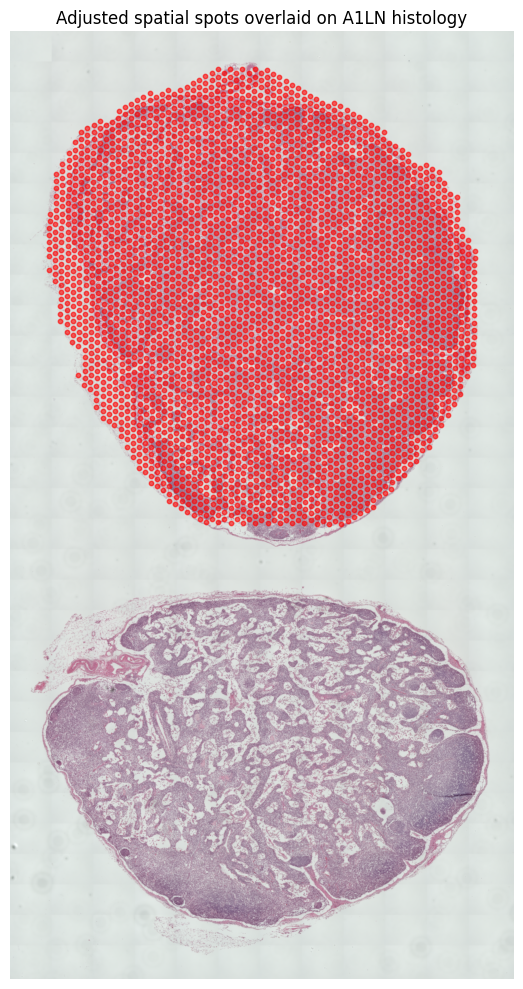

In [3]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

positions = pd.read_csv("GSM8195494_A1LN_tissue_positions.csv.gz", header=None)
positions.columns = ["barcode", "in_tissue", "array_row", "array_col", "image_row", "image_col"]
positions = positions.set_index("barcode")

import scanpy as sc
rna = sc.read("adata_RNA.h5ad")

common_barcodes = rna.obs_names.intersection(positions.index)
rna = rna[common_barcodes]
positions = positions.loc[common_barcodes]


coords = positions[["image_col", "image_row"]].astype(float).values  

img = Image.open("GSM8195494_A1LN_tissue_hires_image.png").convert("RGB")
img_np = np.array(img)

def normalize_coords_adjustable(coords, image_shape, scale_factors=(1.0, 1.0), shift=(0, 0)):
    x_min, y_min = coords.min(axis=0)
    x_max, y_max = coords.max(axis=0)
    coords_norm = (coords - [x_min, y_min]) / ([x_max - x_min, y_max - y_min])
    coords_norm[:, 0] = coords_norm[:, 0] * scale_factors[0] + (1 - scale_factors[0]) / 2
    coords_norm[:, 1] = coords_norm[:, 1] * scale_factors[1] + (1 - scale_factors[1]) / 2
    coords_img = coords_norm * [image_shape[1], image_shape[0]]
    coords_img[:, 0] += shift[0]
    coords_img[:, 1] += shift[1]
    return coords_img.astype(int)


coords_img_adj = normalize_coords_adjustable(
    coords, img_np.shape,
    scale_factors=(0.846, 0.48),  
    shift=(0, -440)              
)


plt.figure(figsize=(10, 10))
plt.imshow(img_np)
plt.scatter(coords_img_adj[:, 0], coords_img_adj[:, 1], s=10, c='red', alpha=0.6)
plt.title("Adjusted spatial spots overlaid on A1LN histology")
plt.axis('off')
plt.tight_layout()
plt.show()


In [4]:
from tqdm import tqdm

def extract_patch_safe(img, center_x, center_y, patch_size):

    h, w, _ = img.shape
    patch = np.ones((patch_size, patch_size, 3), dtype=np.uint8) * 255  

    half = patch_size // 2
    start_x = center_x - half
    start_y = center_y - half
    end_x = center_x + half
    end_y = center_y + half

    img_x1 = max(start_x, 0)
    img_x2 = min(end_x, w)
    img_y1 = max(start_y, 0)
    img_y2 = min(end_y, h)

    patch_x1 = img_x1 - start_x
    patch_x2 = patch_x1 + (img_x2 - img_x1)
    patch_y1 = img_y1 - start_y
    patch_y2 = patch_y1 + (img_y2 - img_y1)

    patch[patch_y1:patch_y2, patch_x1:patch_x2] = img[img_y1:img_y2, img_x1:img_x2]
    return patch


def extract_embeddings_batch_dualscale(
    img,
    coords_img,
    patch_sizes=(24, 32),
    batch_size=128,
    device='cuda'
):  
    import torch
    from PIL import Image
    from gsmo.hist_features_uni import model, transform

    if isinstance(img, Image.Image):
        img = np.array(img.convert("RGB"))

    model.eval()
    model.to(device)

    all_patches_small = []
    all_patches_large = []

    for (x, y) in coords_img:
        patch_small = extract_patch_safe(img, x, y, patch_sizes[0])
        patch_large = extract_patch_safe(img, x, y, patch_sizes[1])
        all_patches_small.append(patch_small)
        all_patches_large.append(patch_large)

    def patches_to_tensor(patch_list):
        return torch.stack([transform(Image.fromarray(p)) for p in patch_list])

    patch_tensors_small = patches_to_tensor(all_patches_small)
    patch_tensors_large = patches_to_tensor(all_patches_large)

    embeddings = []
    with torch.inference_mode():
        for i in tqdm(range(0, len(coords_img), batch_size), desc="Extracting dual-scale embeddings"):
            batch_s = patch_tensors_small[i:i+batch_size].to(device)
            batch_l = patch_tensors_large[i:i+batch_size].to(device)

            emb_s = model(batch_s).cpu().numpy()  # [B, 1536]
            emb_l = model(batch_l).cpu().numpy()
            emb = np.concatenate([emb_s, emb_l], axis=1)  # [B, 3072]
            embeddings.append(emb)

    return np.concatenate(embeddings, axis=0)


embeddings = extract_embeddings_batch_dualscale(
    img=img,
    coords_img=coords_img_adj,
    patch_sizes=(16, 32),  
    batch_size=256,
    device='cuda'
)

print("embedding shape:", embeddings.shape)  # [N, 3072]

np.save("image_embeddings.npy", embeddings)

Extracting dual-scale embeddings: 100%|██████████| 14/14 [02:55<00:00, 12.53s/it]


embedding shape: (3484, 3072)


In [4]:
image_embeddings = np.load("image_embeddings.npy")  # [N, 1536]
assert image_embeddings.shape[0] == rna.shape[0]

In [5]:
#Load data and perform necessary preprocessing
spatial_coords = rna.obsm['spatial'].copy()
print(spatial_coords.shape)
print(rna)
protein = sc.read('adata_ADT.h5ad')

rna.var_names_make_unique()
protein.var_names_make_unique()


def clr_normalize_each_cell(adata, inplace=True):
    
    """Normalize count vector for each cell, i.e. for each row of .X"""

    import scipy

    def seurat_clr(x):
        # TODO: support sparseness
        s = np.sum(np.log1p(x[x > 0]))
        exp = np.exp(s / len(x))
        return np.log1p(x / exp)

    if not inplace:
        adata = adata.copy()
    
    # apply to dense or sparse matrix, along axis. returns dense matrix
    adata.X = np.apply_along_axis(
        seurat_clr, 1, (adata.X.toarray() if scipy.sparse.issparse(adata.X) else np.array(adata.X))
    )
    return adata  
def pca(adata, use_reps=None, n_comps=10):
    
    """Dimension reduction with PCA algorithm"""
    
    from sklearn.decomposition import PCA
    from scipy.sparse.csc import csc_matrix
    from scipy.sparse.csr import csr_matrix
    pca = PCA(n_components=n_comps)
    if use_reps is not None:
       feat_pca = pca.fit_transform(adata.obsm[use_reps])
    else: 
       if isinstance(adata.X, csc_matrix) or isinstance(adata.X, csr_matrix):
          feat_pca = pca.fit_transform(adata.X.toarray()) 
       else:   
          feat_pca = pca.fit_transform(adata.X)
    
    return feat_pca

# RNA
sc.pp.filter_genes(rna, min_cells=10)
sc.pp.highly_variable_genes(rna, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.scale(rna)

adata_omics1_high =  rna[:, rna.var['highly_variable']]
print(adata_omics1_high.shape)

# Protein
protein = clr_normalize_each_cell(protein)
sc.pp.scale(protein)

(3484, 2)
View of AnnData object with n_obs × n_vars = 3484 × 18085
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(3484, 3000)


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="anndata")

features_dict = {
        'rna': adata_omics1_high.X,        
        'protein': protein.X,
        'image': image_embeddings
    }

initial_weights = [1.0, 1.0, 1.0]  

df = pd.read_csv("annotation.csv", sep=',')
true_labels = pd.factorize(df['manual-anno'])[0]

cfg = GSMOConfig
cfg.use_conditional_attention=False
model = GSMO(features_dict, spatial_coords=spatial_coords, device=device, cfg=cfg, trainable_weights=True, initial_weights=initial_weights)

model.load_state_dict(torch.load("best_model.pth"))


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

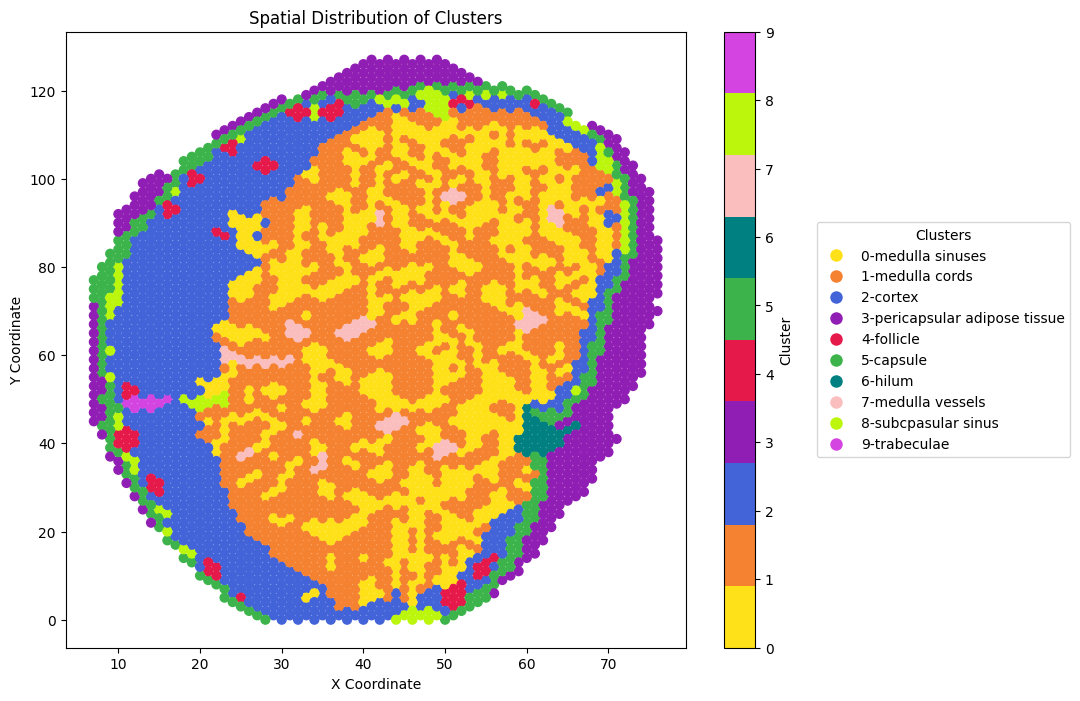

In [7]:
# show GT annotation

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scanpy as sc


plot_color = ['#ffe119', '#f58231', '#4363d8', '#911eb4', '#e6194b', '#3cb44b','#008080','#fabebe', 
              '#bcf60c', '#d344e0','#fabebe', '#008080', '#e6beff', '#9a6324', '#ffd8b1', '#800000', '#aaffc3',  '#808000', 
              '#000075', '#000000', '#808080', '#ffffff', '#fffac8', '#D1D1D1']

rna = sc.read('adata_RNA.h5ad')

rna_locs = rna.obsm['spatial'] 
assert rna_locs is not None and rna_locs.shape[1] == 2, "The RNA data is missing position information or the format is incorrect. Please check the data."

rna_locs_df = pd.DataFrame(rna_locs, columns=['x', 'y'])  
rna_locs_df['cluster'] = true_labels 

num_clusters = len(np.unique(true_labels))


if num_clusters > len(plot_color):
    raise ValueError(f"Cluster number {num_clusters} exceeds the number of colors available in the custom palette {len(plot_color)}.")

cmap = ListedColormap(plot_color[:num_clusters])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(rna_locs_df['x'], rna_locs_df['y'], c=rna_locs_df['cluster'], cmap=cmap, s=40)

legend_labels = ['0-medulla sinuses','1-medulla cords','2-cortex','3-pericapsular adipose tissue','4-follicle','5-capsule','6-hilum','7-medulla vessels','8-subcpasular sinus','9-trabeculae'] 
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i), markersize=10) for i in range(num_clusters)]

plt.legend(handles, legend_labels, title="Clusters", loc='center left', bbox_to_anchor=(1.2, 0.5))

plt.colorbar(scatter, label="Cluster")
plt.title("Spatial Distribution of Clusters")
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


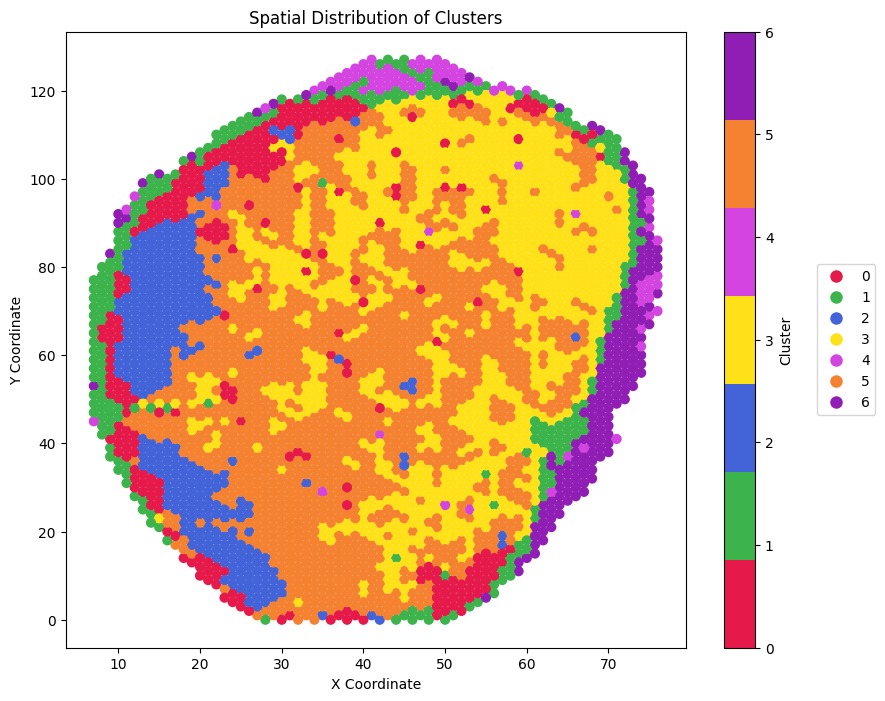

In [8]:
# show GSMO clustering results

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scanpy as sc


plot_color =  ['#e6194b', '#3cb44b', '#4363d8', '#ffe119', '#d344e0', '#f58231','#911eb4','#aaffc3', 
              '#bcf60c', '#f032e6','#fabebe', '#008080', '#e6beff', '#9a6324', '#ffd8b1', '#800000', '#aaffc3',  '#808000', 
              '#000075', '#000000', '#808080', '#ffffff', '#fffac8', '#D1D1D1']

rna = sc.read('adata_RNA.h5ad')

rna_locs = rna.obsm['spatial'] 
assert rna_locs is not None and rna_locs.shape[1] == 2, "The RNA data is missing position information or the format is incorrect. Please check the data."

clusters = model.cluster_kmeans(n_clusters=7)

rna_locs_df = pd.DataFrame(rna_locs, columns=['x', 'y'])  
rna_locs_df['cluster'] = clusters  

num_clusters = len(np.unique(clusters))

if num_clusters > len(plot_color):
    raise ValueError(f"Cluster number {num_clusters} exceeds the number of colors available in the custom palette {len(plot_color)}.")


cmap = ListedColormap(plot_color[:num_clusters])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(rna_locs_df['x'], rna_locs_df['y'], c=rna_locs_df['cluster'], cmap=cmap, s=40)

legend_labels = [f'{i}' for i in range(num_clusters)]  
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i), markersize=10) for i in range(num_clusters)]

plt.legend(handles, legend_labels, loc='center left', bbox_to_anchor=(1.2, 0.5))

plt.colorbar(scatter, label="Cluster")
plt.title("Spatial Distribution of Clusters")
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


In [9]:
# evaluate clustering results using six supervised metrics
from sklearn.metrics import (
    adjusted_rand_score,
    homogeneity_score,
    mutual_info_score,
    v_measure_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
)
import pandas as pd

def evaluate_clustering_metrics(annotation_path, cluster_labels):
    df = pd.read_csv(annotation_path, sep=',')
    true_labels = pd.factorize(df['manual-anno'])[0]

    scores = {
        "ARI": adjusted_rand_score(true_labels, cluster_labels),
        "Homogeneity": homogeneity_score(true_labels, cluster_labels),
        "Mutual Info": mutual_info_score(true_labels, cluster_labels),
        "V-measure": v_measure_score(true_labels, cluster_labels),
        "AMI": adjusted_mutual_info_score(true_labels, cluster_labels),
        "NMI": normalized_mutual_info_score(true_labels, cluster_labels),
    }

    print("=== Clustering Evaluation Metrics ===")
    for k, v in scores.items():
        print(f"{k}: {v:.4f}")
    
    return scores


clusters = model.cluster_kmeans(n_clusters=7)
scores = evaluate_clustering_metrics("annotation.csv", clusters)


=== Clustering Evaluation Metrics ===
ARI: 0.3301
Homogeneity: 0.4013
Mutual Info: 0.6770
V-measure: 0.4150
AMI: 0.4121
NMI: 0.4150


In [10]:
# evaluate using two unsupervised metrics
from sklearn.metrics import pairwise_distances
import numpy as np
from tqdm import tqdm

def compute_jaccard_similarity(Z_m, Z_e, k=50):
    dist_m = pairwise_distances(Z_m)
    dist_e = pairwise_distances(Z_e)
    
    n = Z_m.shape[0]
    jaccard_scores = []

    for i in tqdm(range(n), desc="Calculating Jaccard similarities"):
        neighbors_m = set(np.argsort(dist_m[i])[1:k+1])  # exclude self
        neighbors_e = set(np.argsort(dist_e[i])[1:k+1])
        intersection = len(neighbors_m & neighbors_e)
        union = len(neighbors_m | neighbors_e)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_scores.append(jaccard)

    return np.array(jaccard_scores), np.mean(jaccard_scores)


import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np


def compute_morans_I(labels, spatial_coords, label_name="cluster_label"):
    adata = sc.AnnData(X=np.zeros((len(labels), 1)))  # dummy
    adata.obs[label_name] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    sq.gr.spatial_autocorr(adata, mode="moran", genes=label_name, attr="obs")

    moran_result = adata.uns["moranI"].loc[label_name, "I"]
    return moran_result



fused_embeddings = model.get_embeddings()


# 1. Jaccard
jaccard_all, jaccard_mean = compute_jaccard_similarity(adata_omics1_high.X, fused_embeddings, k=50)
print(f"Mean Jaccard RNA Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(protein.X, fused_embeddings, k=50)
print(f"Mean Jaccard protein Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(image_embeddings, fused_embeddings, k=50)
print(f"Mean Jaccard image Similarity: {jaccard_mean:.4f}")


cluster_labels = model.cluster_kmeans(n_clusters=7)
morans_I = compute_morans_I(cluster_labels, spatial_coords)
print(f"Moran's I score: {morans_I:.4f}")



/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
Calculating Jaccard similarities: 100%|██████████| 3484/3484 [00:00<00:00, 4483.20it/s]


Mean Jaccard RNA Similarity: 0.0164


Calculating Jaccard similarities: 100%|██████████| 3484/3484 [00:00<00:00, 4340.35it/s]


Mean Jaccard protein Similarity: 0.2246


Calculating Jaccard similarities: 100%|██████████| 3484/3484 [00:00<00:00, 4368.97it/s]


Mean Jaccard image Similarity: 0.0693
Moran's I score: 0.5443


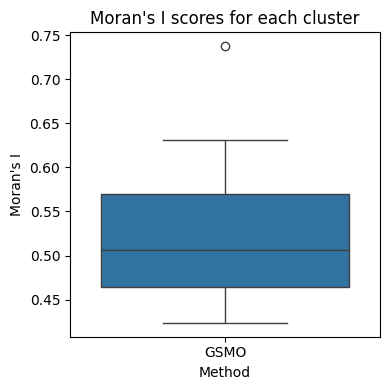

  cluster   moran_I method
0       0  0.492033   GSMO
1       1  0.423603   GSMO
2       2  0.737374   GSMO
3       3  0.507462   GSMO
4       4  0.436685   GSMO
5       5  0.506124   GSMO
6       6  0.631157   GSMO


In [ ]:
# box plot of moran's I score
import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_morans_I_per_method(labels, spatial_coords, method_name="MethodA"):
    adata = sc.AnnData(X=np.zeros((len(labels), 1)))
    adata.obs["cluster_label"] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)


    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    moran_scores = []
    unique_labels = np.unique(labels)

    for label in unique_labels:
        binary_vector = (labels == label).astype(int)
        adata.obs["tmp_binary"] = binary_vector

        sq.gr.spatial_autocorr(adata, mode="moran", genes="tmp_binary", attr="obs")
        I_score = adata.uns["moranI"].loc["tmp_binary", "I"]
        moran_scores.append({
            "cluster": str(label),
            "moran_I": I_score,
            "method": method_name
        })

    df_moran = pd.DataFrame(moran_scores)

    plt.figure(figsize=(4, 4))
    sns.boxplot(data=df_moran, x="method", y="moran_I")
    plt.title("Moran's I scores for each cluster")
    plt.ylabel("Moran's I")
    plt.xlabel("Method")
    plt.tight_layout()
    plt.show()

    return df_moran

morans_I_df = compute_morans_I_per_method(cluster_labels, spatial_coords, method_name="GSMO")
print(morans_I_df)


=== supervised metrics across clusters ===
 n_clusters      ARI  Homogeneity  Mutual Info  V-measure      AMI      NMI
          4 0.334852     0.337366     0.569137   0.390862 0.389179 0.390862
          5 0.322048     0.343692     0.579810   0.387196 0.384996 0.387196
          6 0.331883     0.382814     0.645808   0.408846 0.406322 0.408846
          7 0.330084     0.401332     0.677049   0.414984 0.412076 0.414984
          8 0.283973     0.403512     0.680726   0.392941 0.389619 0.392941
          9 0.224287     0.412461     0.695824   0.379547 0.375876 0.379547
         10 0.224013     0.413378     0.697370   0.378040 0.373966 0.378040
         11 0.202404     0.417370     0.704105   0.364807 0.360378 0.364807


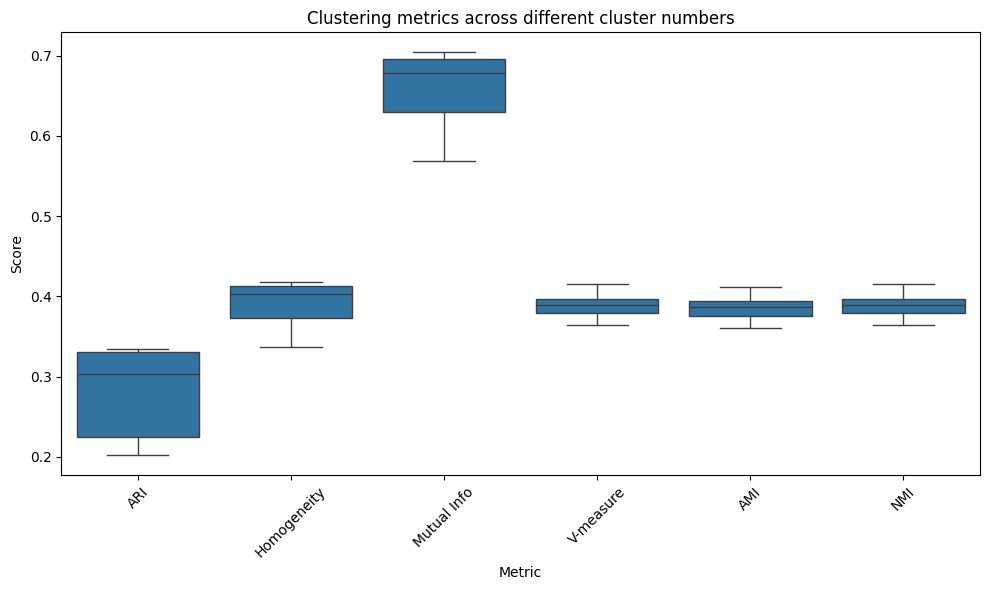

In [13]:
# box plot of supervised metrics
import pandas as pd
import numpy as np
from sklearn.metrics import (
    adjusted_rand_score,
    homogeneity_score,
    mutual_info_score,
    v_measure_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
)
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_clustering_metrics_over_k(annotation_path, model, cluster_range=range(4, 12)):
    # 读取注释文件
    df = pd.read_csv(annotation_path)
    true_labels = pd.factorize(df['manual-anno'])[0]

    all_scores = []

    for k in cluster_range:
        pred_labels = model.cluster_kmeans(n_clusters=k)

        scores = {
            "n_clusters": k,
            "ARI": adjusted_rand_score(true_labels, pred_labels),
            "Homogeneity": homogeneity_score(true_labels, pred_labels),
            "Mutual Info": mutual_info_score(true_labels, pred_labels),
            "V-measure": v_measure_score(true_labels, pred_labels),
            "AMI": adjusted_mutual_info_score(true_labels, pred_labels),
            "NMI": normalized_mutual_info_score(true_labels, pred_labels),
        }

        all_scores.append(scores)

    results_df = pd.DataFrame(all_scores)

    print("=== supervised metrics across clusters ===")
    print(results_df.to_string(index=False))

    df_long = results_df.melt(id_vars="n_clusters", var_name="Metric", value_name="Score")

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_long, x="Metric", y="Score")
    plt.title("Clustering metrics across different cluster numbers")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return results_df

results = evaluate_clustering_metrics_over_k("annotation.csv", model)


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldc

<Figure size 1200x1000 with 0 Axes>

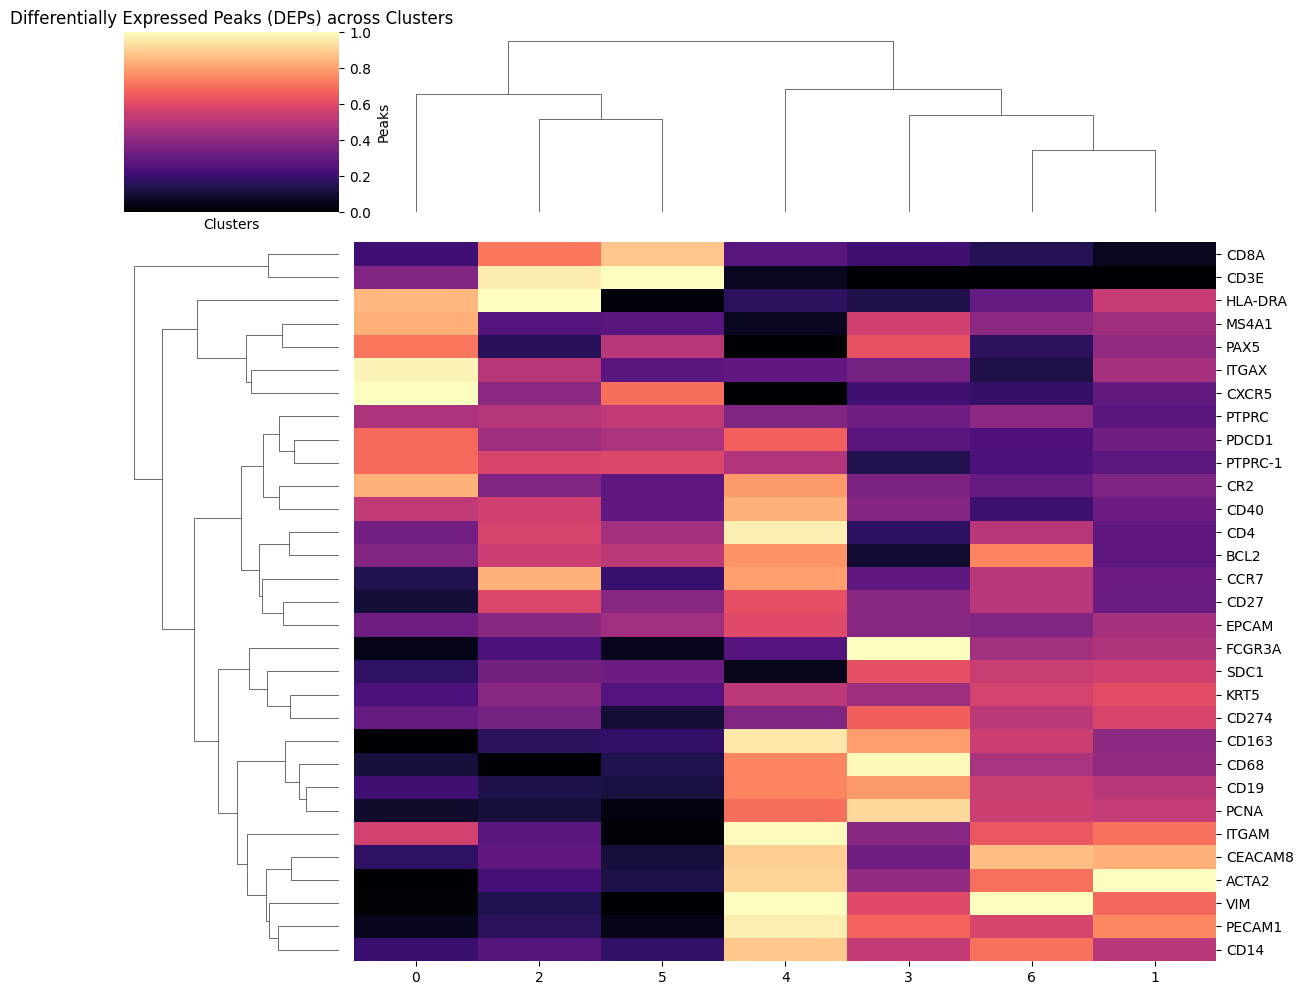

In [14]:
# DEP(protein)

import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

adata2=protein.copy()
adata2.obs['GSMO'] =clusters
adata2.obs['GSMO'] = pd.Categorical(adata2.obs['GSMO'])

sc.tl.rank_genes_groups(adata2, groupby='GSMO', method='t-test', n_genes=31)  

deg_results = adata2.uns['rank_genes_groups']
deg_df = pd.DataFrame(deg_results['names']).T  

top_peaks = deg_df.iloc[0].values  

adata2.raw = adata2  
sc.pp.scale(adata2, zero_center=True) 

deg_peak_expression = []


for peak in top_peaks:
    peak_expression = []
    for cluster in np.unique(adata2.obs['GSMO']):
        cluster_cells = adata2[adata2.obs['GSMO'] == cluster]
        peak_expression.append(cluster_cells[:, peak].X.toarray().mean())
    deg_peak_expression.append(peak_expression)

deg_peak_expression = np.array(deg_peak_expression)
deg_peak_expression_df = pd.DataFrame(deg_peak_expression, columns=np.unique(adata2.obs['GSMO']), index=top_peaks)

peak_order = deg_peak_expression_df.mean(axis=1).sort_values(ascending=False).index
deg_peak_expression_df = deg_peak_expression_df.loc[peak_order, :]


cluster_order = deg_peak_expression_df.mean(axis=0).sort_values(ascending=False).index
deg_peak_expression_df = deg_peak_expression_df.loc[:, cluster_order]
cmap = 'magma'

plt.figure(figsize=(12, 10))  


sns.clustermap(deg_peak_expression_df, figsize=(12, 10), cmap=cmap, annot=False, standard_scale=1, cbar_kws={'label': 'Peak Expression'})

plt.title("Differentially Expressed Peaks (DEPs) across Clusters")
plt.xlabel("Clusters")
plt.ylabel("Peaks")
plt.tight_layout()
plt.show()

# plt.savefig("DEG_heatmap_sorted.png", dpi=300, bbox_inches='tight')


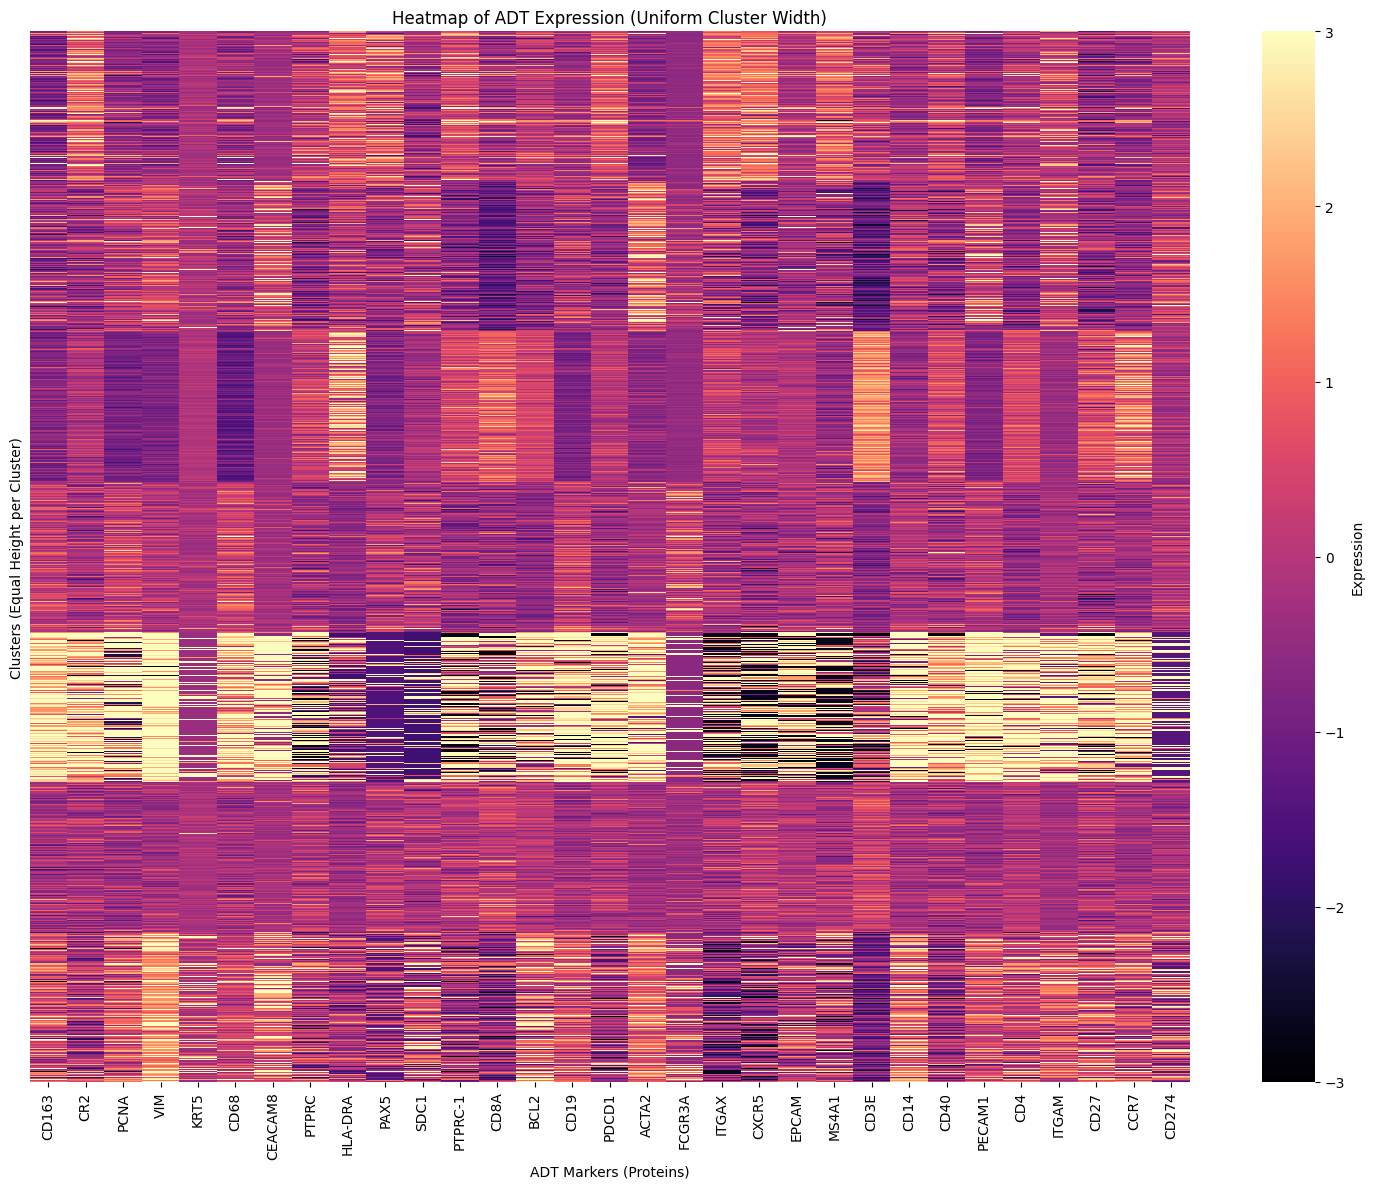

In [ ]:
# heat map of cell-level ADT

import scanpy as sc 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

adata2 = protein.copy()
adata = protein.copy()

clusters = model.cluster_kmeans(n_clusters=7)
adata.obs['GSMO'] = pd.Categorical(clusters)

adt_data = adata2.X
if not isinstance(adt_data, np.ndarray):
    adt_data = adt_data.toarray()
sc.pp.scale(adata2)
expr_z = (adt_data - np.mean(adt_data)) / np.std(adt_data)
expr_scaled = np.clip(expr_z, -3, 3)  

adt_df = pd.DataFrame(expr_scaled, columns=adata2.var_names, index=adata2.obs_names)
adt_df['cluster'] = adata.obs['GSMO'].values

n_cells_per_cluster = 600  
clustered_dfs = []

for cluster in sorted(adt_df['cluster'].unique()):
    cluster_df = adt_df[adt_df['cluster'] == cluster].drop(columns='cluster')
    if len(cluster_df) >= n_cells_per_cluster:
        sampled = cluster_df.sample(n=n_cells_per_cluster, random_state=0)
    else:
        sampled = cluster_df.sample(n=n_cells_per_cluster, replace=True, random_state=0)
    sampled['cluster'] = cluster
    clustered_dfs.append(sampled)


uniform_df = pd.concat(clustered_dfs)
uniform_df_sorted = uniform_df.sort_values(by='cluster')
uniform_df_clean = uniform_df_sorted.drop(columns='cluster')

plt.figure(figsize=(15, 12))
cmap = LinearSegmentedColormap.from_list("custom_magma", ["#ffffff", "#d3d3d3", "#ff1919"])

sns.heatmap(uniform_df_clean, cmap='magma', annot=False,
            cbar_kws={'label': 'Expression'}, xticklabels=True,
            yticklabels=False, linewidths=0)

ax = plt.gca()
cluster_labels = uniform_df_sorted['cluster'].values
cluster_start = 0
for cluster in sorted(np.unique(cluster_labels)):
    cluster_end = cluster_start + n_cells_per_cluster - 1
    ax.add_patch(Rectangle((0, cluster_start), len(uniform_df_clean.columns), n_cells_per_cluster,
                           linewidth=0, edgecolor='white', facecolor='none'))
    cluster_start = cluster_end + 1

plt.title("Heatmap of ADT Expression (Uniform Cluster Width)")
plt.xlabel("ADT Markers (Proteins)")
plt.ylabel("Clusters (Equal Height per Cluster)")
plt.tight_layout()

# plt.savefig("ADT_heatmap_over_clusters.png", dpi=600, bbox_inches='tight')
plt.show()


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:235: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


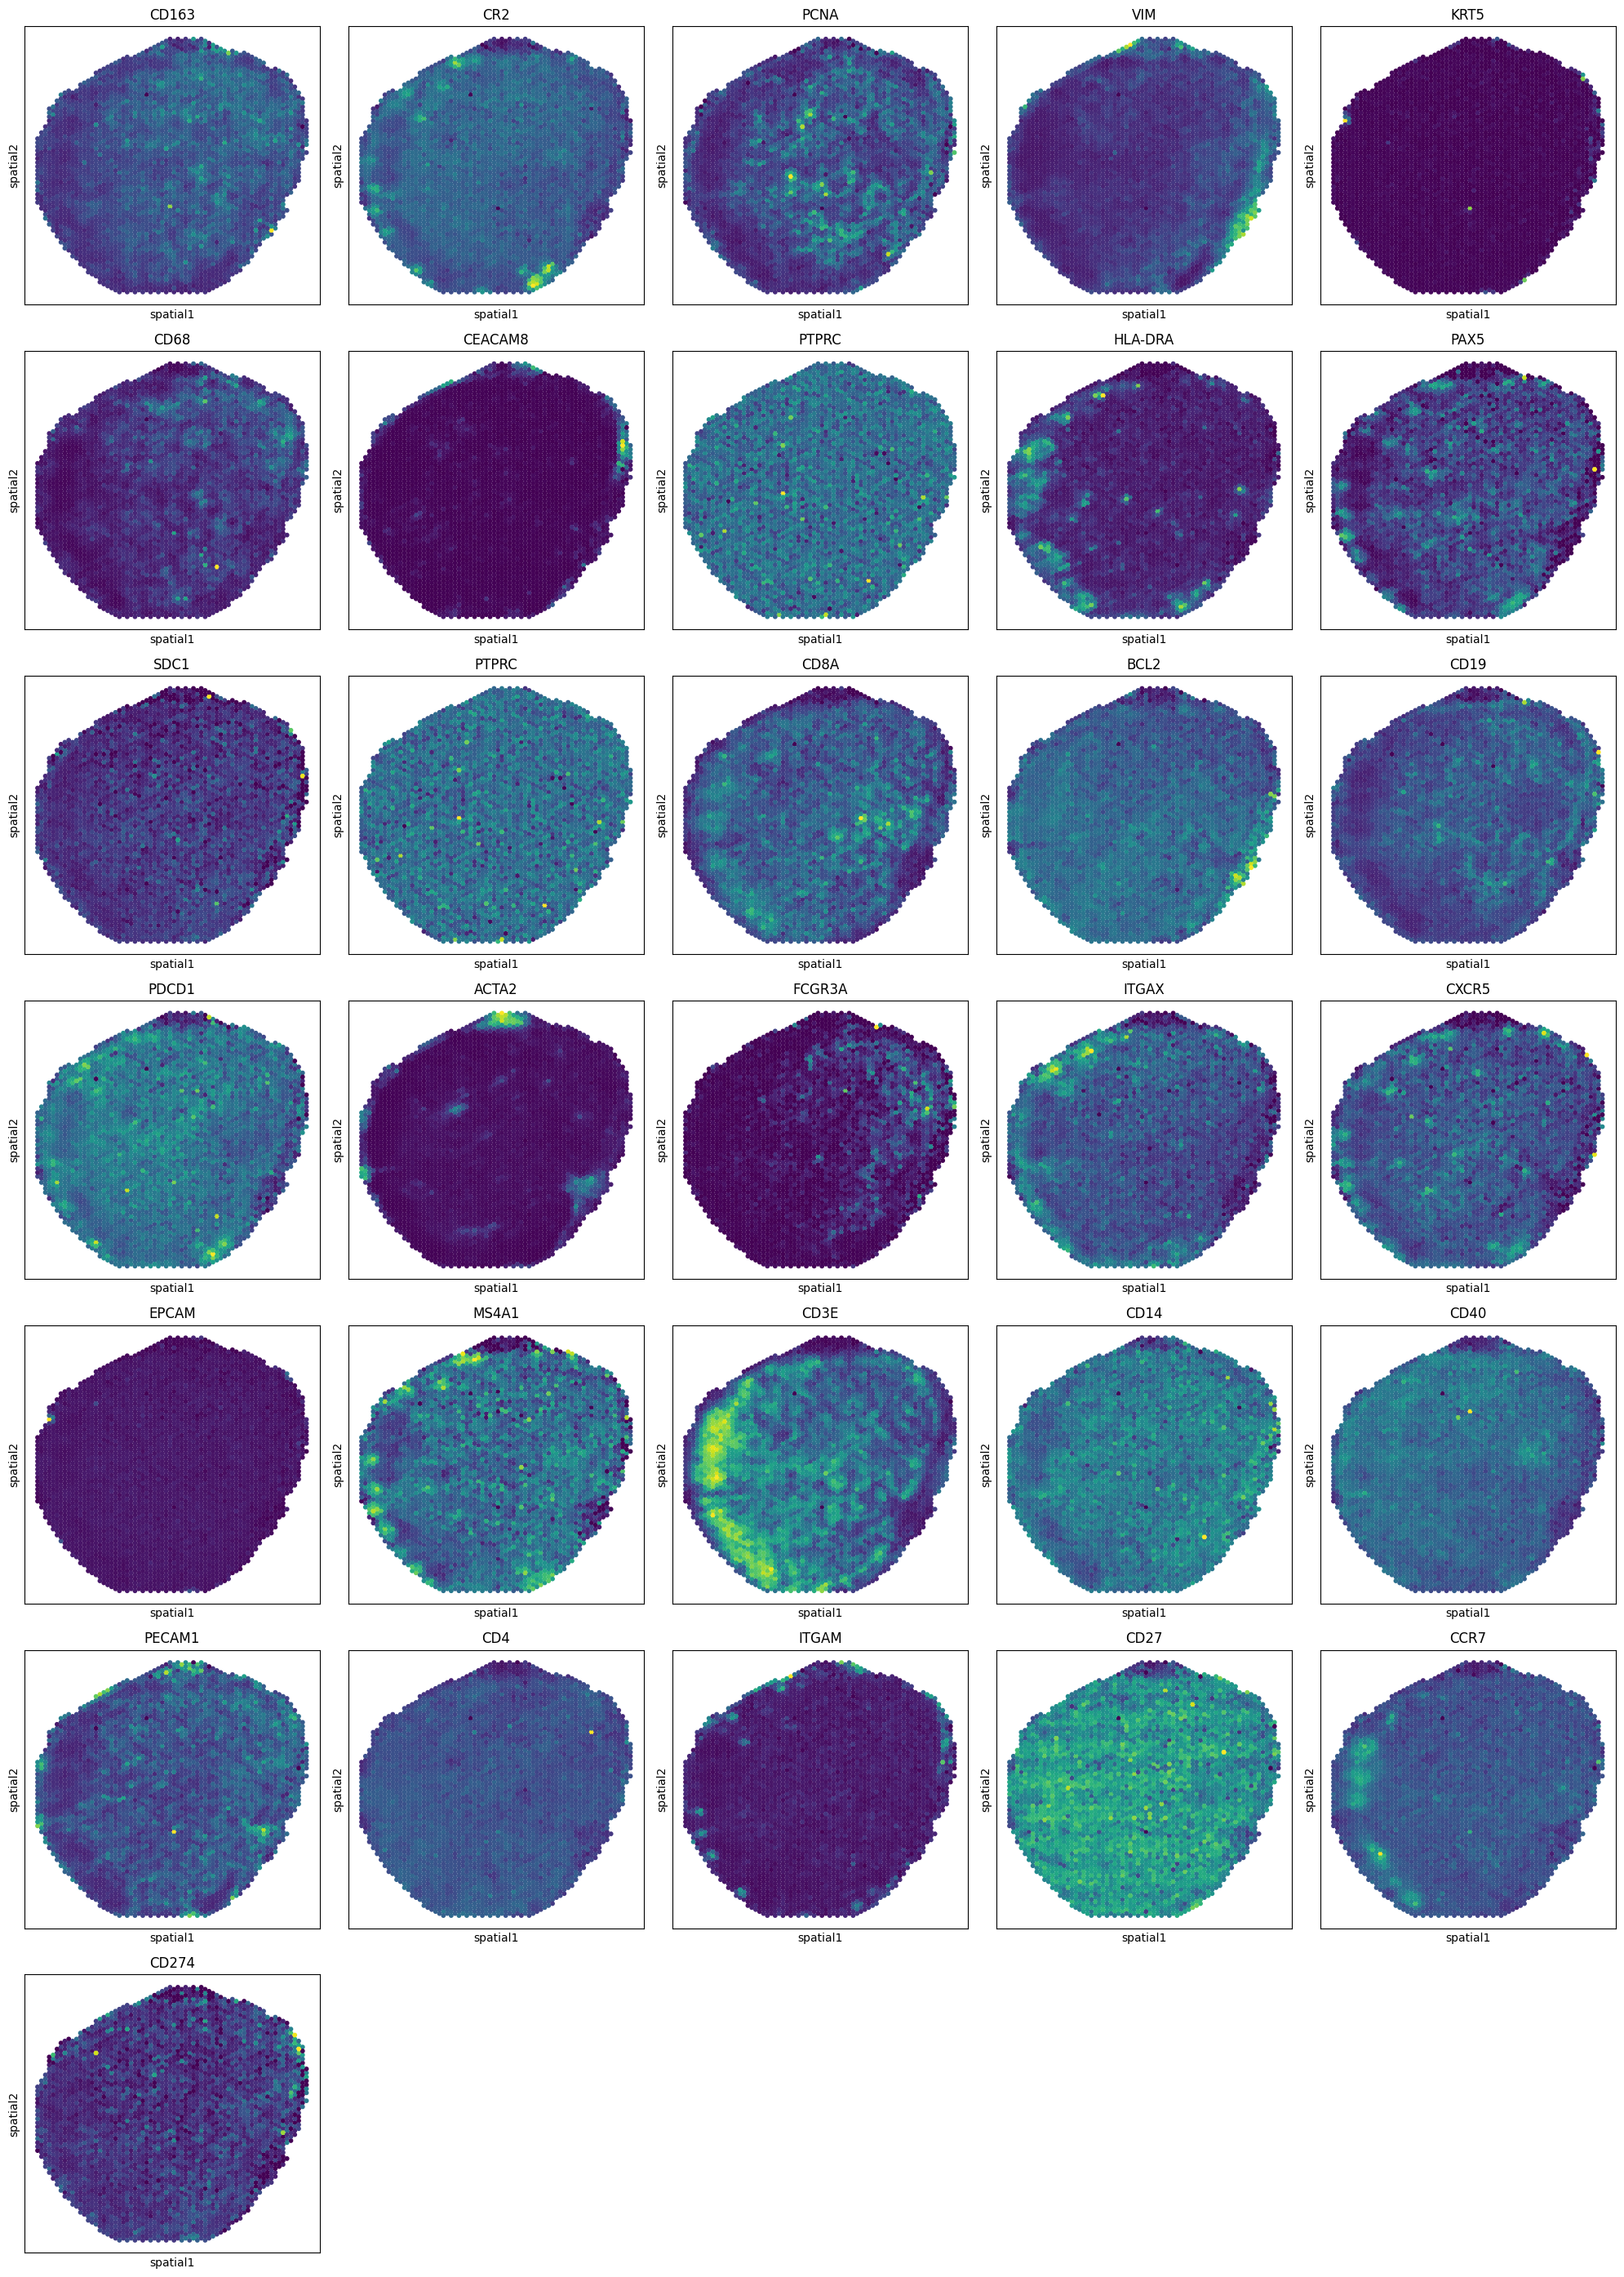

In [ ]:
# heat map of expressions of all proteins
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

adata_p = sc.read('adata_ADT.h5ad')

sc.pp.normalize_total(adata_p, target_sum=1e4)
sc.pp.scale(adata_p, zero_center=True)

coords = adata_p.obsm['spatial']
x = coords[:, 0]
y = coords[:, 1]


proteins = adata_p.var_names.tolist()

n_cols = 5
n_rows = int(np.ceil(len(proteins) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, protein in enumerate(proteins):
    ax = axes[i]
    spatial_idx = adata_p.obsm['spatial'].index if isinstance(adata_p.obsm['spatial'], pd.DataFrame) else adata_p.obs_names[:coords.shape[0]]
    
    expr = adata_p.obs_vector(protein)[:coords.shape[0]]

    scatter = ax.scatter(x, y, c=expr, cmap='viridis', s=10, alpha=1.0)

    ax.set_title(protein)
    ax.set_xlabel('spatial1')
    ax.set_ylabel('spatial2')
    ax.set_xticks([])
    ax.set_yticks([])

for j in range(len(proteins), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# plt.savefig("ADT_heatmap.jpg", dpi=600, bbox_inches='tight')
plt.show()